In [42]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [43]:
def RK4(a, b, N, alpha, phuongtrinh):
    h = (b - a) / N                  # tinh kich thuoc buoc thoi gian
    x = np.linspace(a, b, N + 1)     # tao mang thoi gian tu a den b gom N+1 diem
    y = np.zeros((N + 1, len(alpha)))# tao mang nghiem cho he ODE
    y[0] = alpha                     # gan dieu kien dau

    for i in range(N):               # lap qua tung buoc thoi gian
        k1 = phuongtrinh(x[i], y[i]) # dao ham tai dau buoc
        k2 = phuongtrinh(x[i] + h/2, y[i] + h*k1/2) # dao ham tai diem giua dung k1
        k3 = phuongtrinh(x[i] + h/2, y[i] + h*k2/2) # dao ham tai diem giua dung k2
        k4 = phuongtrinh(x[i] + h, y[i] + h*k3)     # dao ham tai cuoi buoc

        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6 # cap nhat nghiem RK4

    return x, y                      # tra ve mang thoi gian va nghiem

In [44]:
def conlac_daodong(t, Y):
    global g, l, q, omega_D, g_d

    theta = Y[0]   # goc lech Y(theta,omega)
    omega = Y[1]   # van toc goc 

    dtheta_dt = omega
    domega_dt = -1/q*omega -np.sin(theta) + g_d*np.cos(omega_D*t)

    # F[0] = theta0
    # F[1] = omega0 
    F = np.array([dtheta_dt, domega_dt])
    return F

In [45]:
g = 9.81
l = 9.81
t_min = 0
t_max = 5000
N_t = 100000

theta0 = 3
omega0 = 0.0

q = 2
g_d = 1.5
omega_D = 2/3
Y0_conlac = np.array([theta0, omega0]) 

In [46]:
t_conlac, Y_conlac = RK4(t_min,t_max,N_t,Y0_conlac, conlac_daodong)

#Y_conlac =
#[
#    [theta0, omega0],
#    [theta1, omega1],
#    [theta2, omega2],
#    ...
#]

def ghifile(t, Y, filename="conlac-RK4"):
    filename = f"KQ_{filename}.txt"

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Giai bai toan con lac bang RK4\n")
        file.write("#\n")
        file.write(f"# {'t':>20s} {'theta':>20s} {'omega':>20s}\n")

        for t_step in range(len(t)):
            file.write(f"  {t[t_step]:20.8e} {Y[t_step, 0]:20.8e} {Y[t_step, 1]:20.8e}\n")

ghifile(t_conlac, Y_conlac, filename="conlac-chaos-RK4")

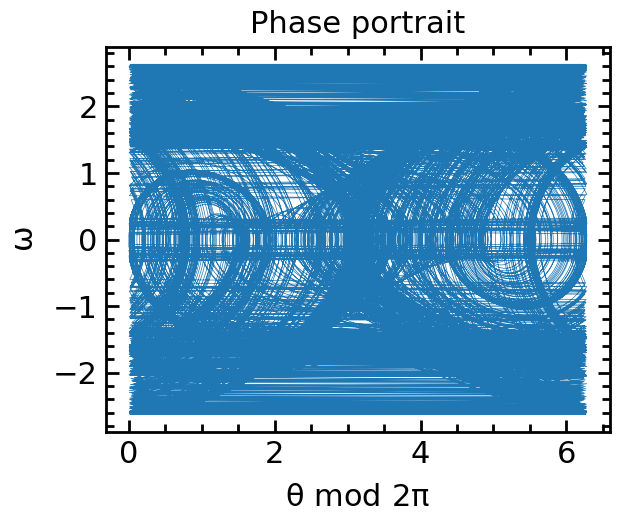

In [47]:
theta = Y_conlac[:, 0]
omega = Y_conlac[:, 1]

theta_mod = np.mod(theta, 2*np.pi)

plt.figure()
plt.plot(theta_mod, omega, lw=0.5)
plt.xlabel(r'$\theta \ \mathrm{mod}\ 2\pi$')
plt.ylabel(r'$\omega$')
plt.title('Phase portrait')
plt.show()

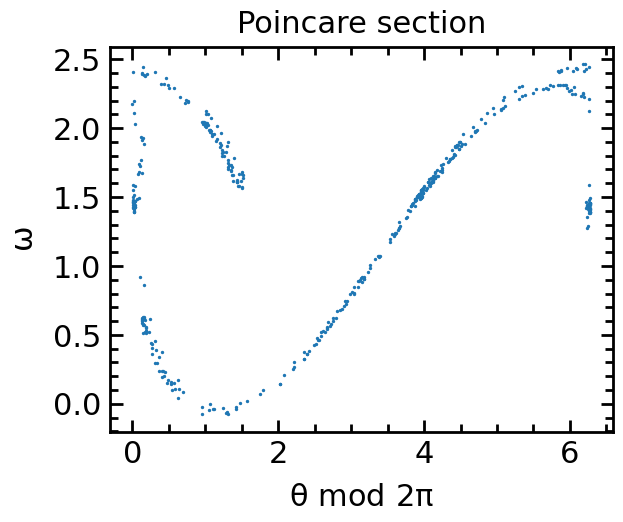

In [48]:
T_D = 2*np.pi / omega_D

n_max = int(t_conlac[-1] / T_D)
t_sample = np.arange(1, n_max) * T_D

idx = np.searchsorted(t_conlac, t_sample)

theta_p = np.mod(Y_conlac[idx, 0], 2*np.pi)
omega_p = Y_conlac[idx, 1]

bo_qua = 50
theta_p = theta_p[bo_qua:]
omega_p = omega_p[bo_qua:]

plt.figure()
plt.scatter(theta_p, omega_p, s=2)
plt.xlabel(r'$\theta \ \mathrm{mod}\ 2\pi$')
plt.ylabel(r'$\omega$')
plt.title('Poincare section')
plt.show()